# Multi-class Model Training notebook

1. Preparation du jeu de donnees

In [7]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time
import time

from sklearn.preprocessing import LabelEncoder

# Model Selection
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Save models
import joblib

In [8]:
df = pd.read_csv("../data/processed/cicids2017_clean.csv")
print(df.shape)

(2520798, 70)


Encode the labels

In [9]:
label_encoder = LabelEncoder()

df["Label_encoded"] = label_encoder.fit_transform(df["Label"])

Verification

In [10]:
print(df[["Label", "Label_encoded"]].head())

print(label_encoder.classes_)

    Label  Label_encoded
0  BENIGN              0
1  BENIGN              0
2  BENIGN              0
3  BENIGN              0
4  BENIGN              0
['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


Save the encoder

In [11]:
joblib.dump(
    label_encoder,
    "../models/multiclass_label_encoder.pkl"
)

['../models/multiclass_label_encoder.pkl']

In [12]:
def validate_dataset(df):

    print("=" * 50)
    print("DATASET VALIDATION")
    print("=" * 50)

    # Required columns
    assert "Label" in df.columns, \
        "Label column is missing."

    assert "Label_encoded" in df.columns, \
        "Label_encoded column is missing."

    # Missing values
    assert df.isnull().sum().sum() == 0, \
        "Missing values detected."

    # Infinite values (numeric columns only)
    numeric = df.select_dtypes(include=[np.number])

    assert np.isinf(numeric).sum().sum() == 0, \
        "Infinite values detected."

    # Duplicate rows
    assert df.duplicated().sum() == 0, \
        "Duplicate rows detected."

    # Label encoding consistency
    assert df["Label"].nunique() == df["Label_encoded"].nunique(), \
        "Mismatch between Label and Label_encoded."

    # Display information
    print(f"Shape              : {df.shape}")
    print(f"Number of classes  : {df['Label'].nunique()}")

    print("\nClass distribution:")
    print(df["Label"].value_counts())

    print("\nDataset validation passed.")
validate_dataset(df)


DATASET VALIDATION
Shape              : (2520798, 71)
Number of classes  : 15

Class distribution:
Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Dataset validation passed.


Prepare features and target :

In [13]:
X = df.drop(columns=["Label", "Label_encoded"])

y = df["Label_encoded"]

In [14]:
# Verify no target leakage
assert "Label" not in X.columns
assert "Label_encoded" not in X.columns

print("No target leakage detected.")

No target leakage detected.


Train/Test Split 

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

Verify the split

In [16]:
print("Training set :", X_train.shape)
print("Testing set  :", X_test.shape)

Training set : (2016638, 69)
Testing set  : (504160, 69)


results container 

In [17]:
results = []

Evaluation function

In [18]:
def evaluate_model(model, model_name):

    print("="*60)
    print(model_name)
    print("="*60)

    # ------------------------
    # Training
    # ------------------------

    start_train = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_train

    # ------------------------
    # Prediction
    # ------------------------

    start_pred = time.time()

    y_pred = model.predict(X_test)

    prediction_time = time.time() - start_pred

    # ------------------------
    # Metrics
    # ------------------------

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    # ------------------------
    # Print Metrics
    # ------------------------

    print("\nClassification Report:\n")

    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    print(f"Accuracy       : {accuracy:.6f}")
    print(f"Precision      : {precision:.6f}")
    print(f"Recall         : {recall:.6f}")
    print(f"Weighted F1    : {weighted_f1:.6f}")
    print(f"Macro F1       : {macro_f1:.6f}")
    print(f"Training Time  : {train_time:.2f} sec")
    print(f"Prediction Time: {prediction_time:.2f} sec")

    # ------------------------
    # Confusion Matrix
    # ------------------------

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(14, 12))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.title(f"Matrice de confusion - {model_name}")

    plt.tight_layout()
    plt.show()

    # ------------------------
    # Save Results
    # ------------------------

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Weighted F1": weighted_f1,
        "Macro F1": macro_f1,
        "Training Time (s)": train_time,
        "Prediction Time (s)": prediction_time
    })

    return model

Decision Tree

Decision Tree

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419012
           1       0.80      0.84      0.82       390
           2       1.00      1.00      1.00     25603
           3       0.99      0.99      0.99      2057
           4       1.00      1.00      1.00     34569
           5       0.98      0.99      0.99      1046
           6       0.99      0.99      0.99      1077
           7       1.00      1.00      1.00      1186
           8       1.00      0.50      0.67         2
           9       0.86      0.86      0.86         7
          10       0.99      0.98      0.99     18139
          11       1.00      1.00      1.00       644
          12       0.75      0.73      0.74       294
          13       1.00      0.75      0.86         4
          14       0.44      0.46      0.45       130

    accuracy                           1.00    504160
   macro avg       0.92      0.87      0.

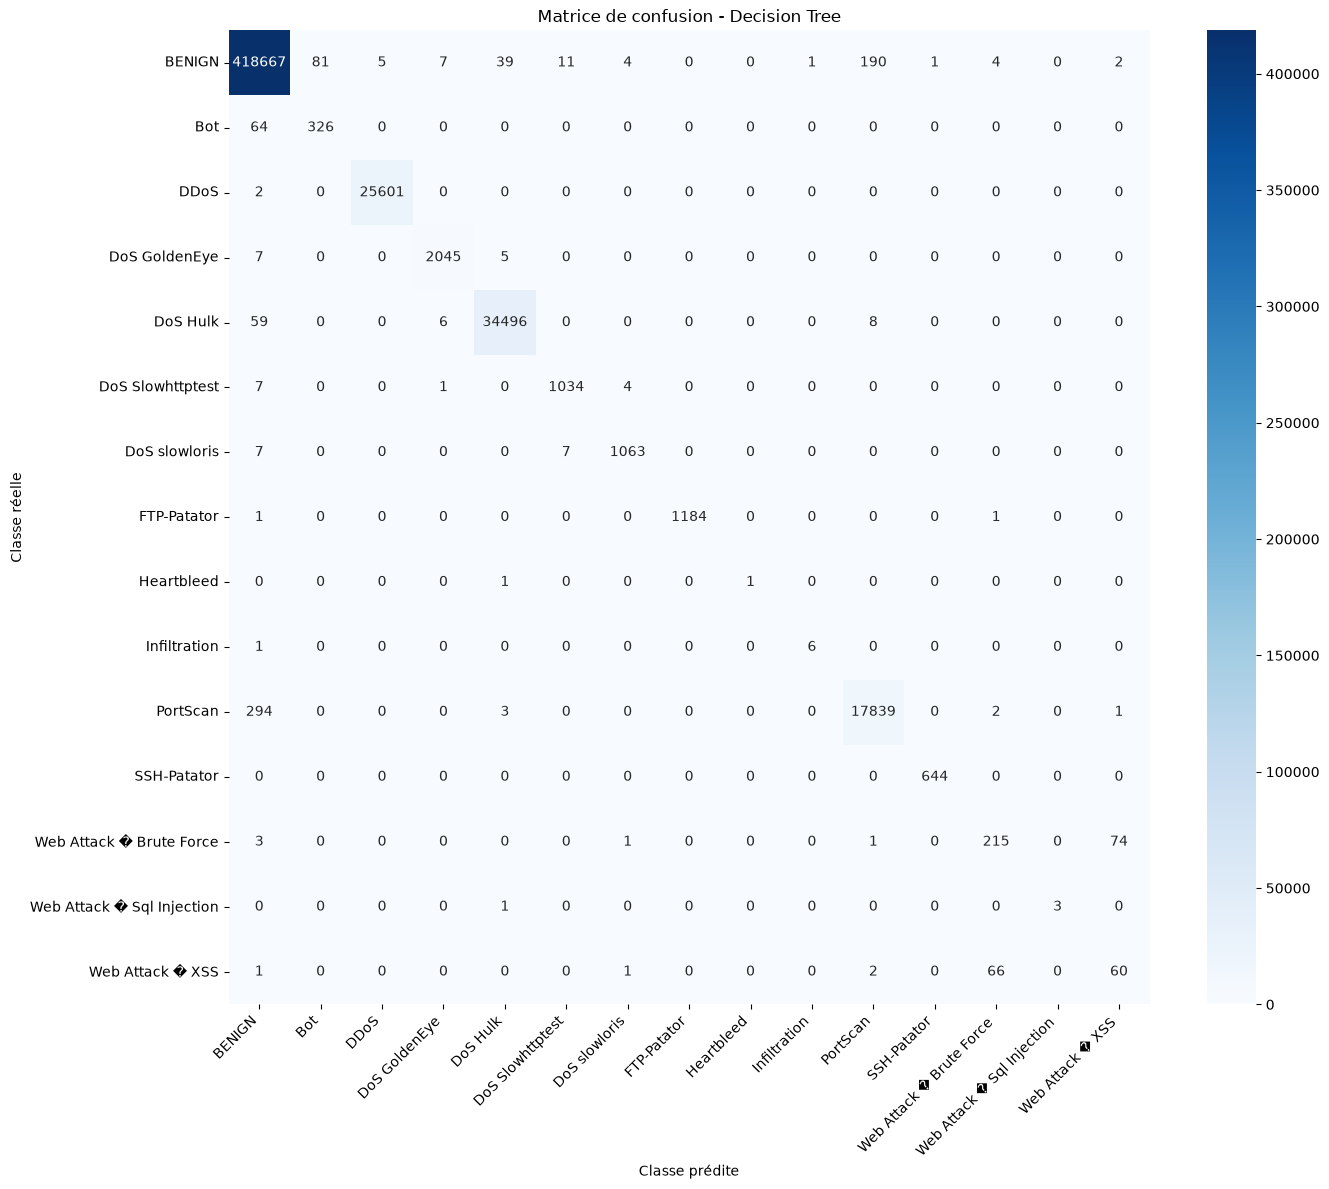

In [19]:
decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree = evaluate_model(
    decision_tree,
    "Decision Tree"
)

Random Forest

Random Forest

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419012
           1       0.88      0.77      0.82       390
           2       1.00      1.00      1.00     25603
           3       1.00      0.99      0.99      2057
           4       1.00      1.00      1.00     34569
           5       0.99      1.00      0.99      1046
           6       1.00      0.99      0.99      1077
           7       1.00      1.00      1.00      1186
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         7
          10       0.99      0.99      0.99     18139
          11       1.00      1.00      1.00       644
          12       0.73      0.82      0.77       294
          13       1.00      0.25      0.40         4
          14       0.42      0.30      0.35       130

    accuracy                           1.00    504160
   macro avg       0.93      0.87      0.

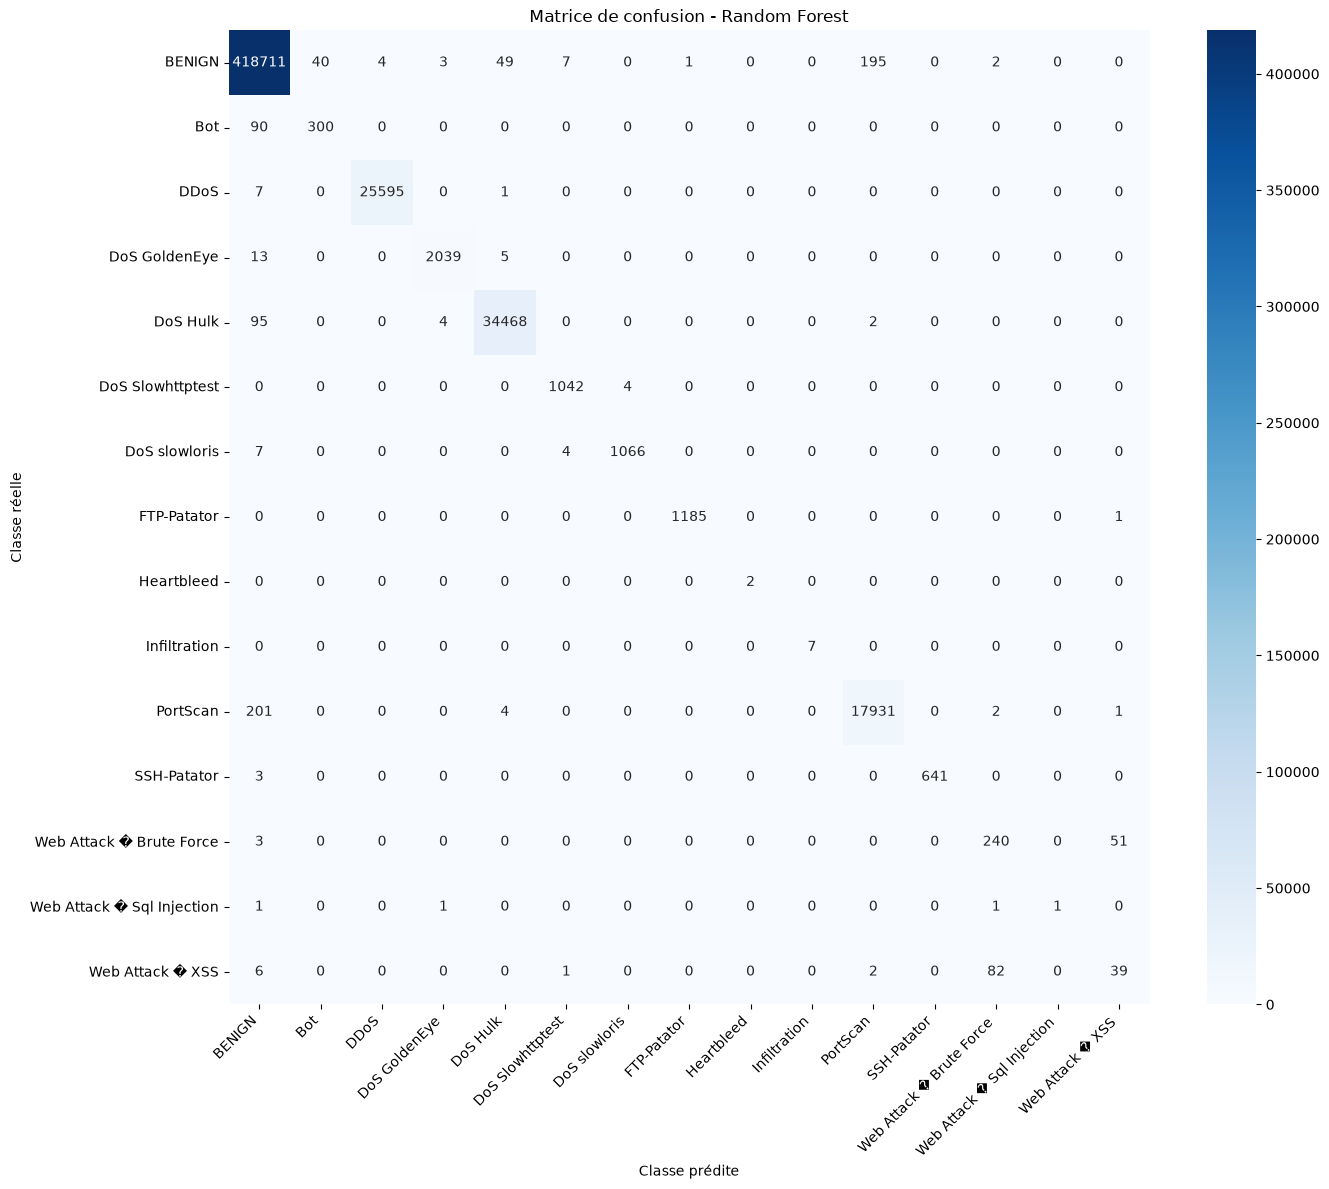

In [20]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest = evaluate_model(
    random_forest,
    "Random Forest"
)

XGBoost

XGBoost

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419012
           1       0.35      0.30      0.32       390
           2       1.00      1.00      1.00     25603
           3       0.96      0.96      0.96      2057
           4       0.99      0.99      0.99     34569
           5       0.76      0.90      0.82      1046
           6       0.70      0.64      0.67      1077
           7       0.95      0.98      0.97      1186
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.97      0.97      0.97     18139
          11       0.92      0.91      0.92       644
          12       0.57      0.65      0.61       294
          13       0.00      0.00      0.00         4
          14       0.42      0.34      0.37       130

    accuracy                           0.99    504160
   macro avg       0.64      0.64      0.64    

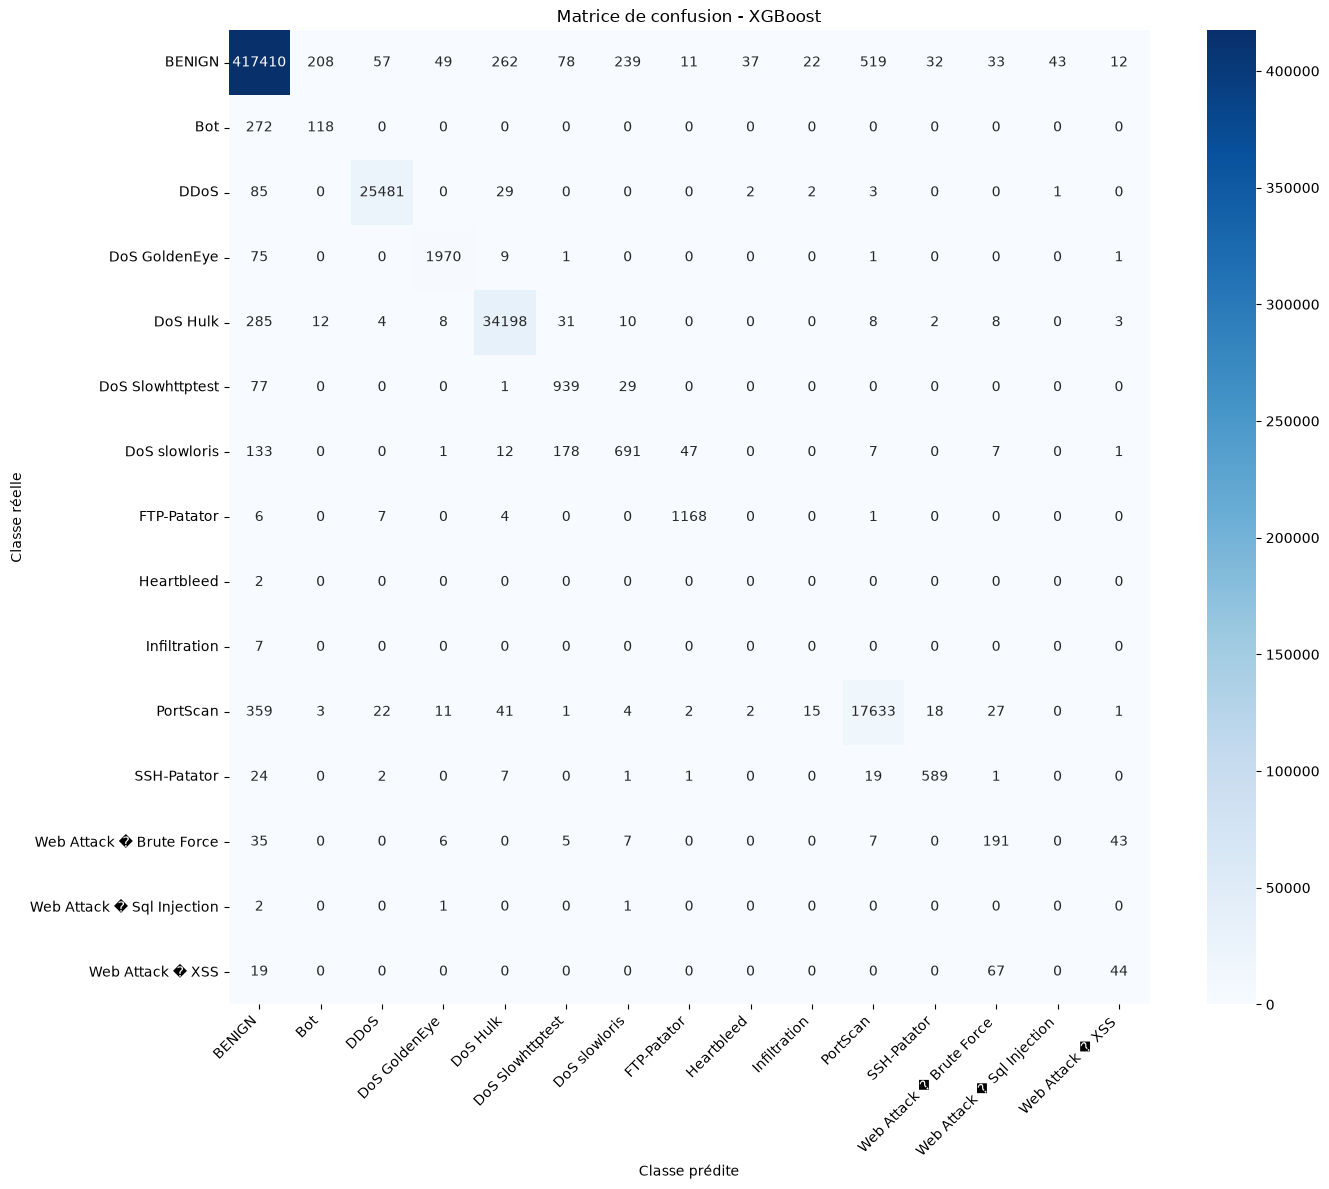

In [21]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb = evaluate_model(
    xgb,
    "XGBoost"
)

In [22]:
df.dtypes

Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                              str
Label_encoded                    int64
Length: 71, dtype: object

Comparison Table

In [23]:
comparison = pd.DataFrame(results)

comparison

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Training Time (s),Prediction Time (s)
0,Decision Tree,0.998064,0.998074,0.998064,0.998068,0.889147,235.119765,0.378893
1,Random Forest,0.998229,0.998191,0.998229,0.998201,0.887164,397.116783,2.976299
2,XGBoost,0.992606,0.992805,0.992606,0.992686,0.639818,451.376963,5.427519


Save Models

In [24]:
joblib.dump(decision_tree, "../models/decision_tree_multiclass.pkl")

joblib.dump(random_forest, "../models/random_forest_multiclass.pkl")

joblib.dump(xgb, "../models/xgboost_multiclass.pkl")

['../models/xgboost_multiclass.pkl']

K-Fold Cross Validation (Decision Tree)

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

In [26]:
def cross_validate_model(model, model_name):

    print("=" * 60)
    print(f"{model_name} - 5-Fold Cross Validation")
    print("=" * 60)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision_weighted",
        "recall": "recall_weighted",
        "weighted_f1": "f1_weighted",
        "macro_f1": "f1_macro"
    }

    cv_results = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    results_cv = pd.DataFrame({
        "Fold": range(1, 6),
        "Accuracy": cv_results["test_accuracy"],
        "Precision": cv_results["test_precision"],
        "Recall": cv_results["test_recall"],
        "Weighted F1": cv_results["test_weighted_f1"],
        "Macro F1": cv_results["test_macro_f1"]
    })

    print(results_cv)

    print("\nAverage Results\n")

    print(f"Accuracy    : {cv_results['test_accuracy'].mean():.6f} ± {cv_results['test_accuracy'].std():.6f}")
    print(f"Precision   : {cv_results['test_precision'].mean():.6f} ± {cv_results['test_precision'].std():.6f}")
    print(f"Recall      : {cv_results['test_recall'].mean():.6f} ± {cv_results['test_recall'].std():.6f}")
    print(f"Weighted F1 : {cv_results['test_weighted_f1'].mean():.6f} ± {cv_results['test_weighted_f1'].std():.6f}")
    print(f"Macro F1    : {cv_results['test_macro_f1'].mean():.6f} ± {cv_results['test_macro_f1'].std():.6f}")

    return results_cv

In [27]:
cv_results = cross_validate_model(
    DecisionTreeClassifier(random_state=42),
    "Decision Tree"
)

Decision Tree - 5-Fold Cross Validation
   Fold  Accuracy  Precision    Recall  Weighted F1  Macro F1
0     1  0.998068   0.998073  0.998068     0.998068  0.879471
1     2  0.998056   0.998049  0.998056     0.998050  0.876653
2     3  0.998114   0.998124  0.998114     0.998117  0.856981
3     4  0.998036   0.998047  0.998036     0.998040  0.872087
4     5  0.997975   0.997983  0.997975     0.997977  0.836256

Average Results

Accuracy    : 0.998050 ± 0.000045
Precision   : 0.998055 ± 0.000046
Recall      : 0.998050 ± 0.000045
Weighted F1 : 0.998051 ± 0.000045
Macro F1    : 0.864290 ± 0.016021
